## Cài đặt thư viện

In [ ]:
!pip install -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 997.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.1 MB/s eta 0:00:00


In [ ]:
# Load the Drive helper and mount
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/Cole_Giảng dạy/OCR_Understanding Document/OCR_Document/Phase 1 Tổng quan về mô hình ai truyền thống/Buổi 2 - Text Detection/Code_segment

[Errno 2] No such file or directory: '/content/drive/MyDrive/Cole_Giảng dạy/OCR_Understanding Document/OCR_Document/Phase 1 Tổng quan về mô hình ai truyền thống/Buổi 2 - Text Detection/Compare_text_detection'
/content


In [ ]:
%ls

final_bill_0.jpg      Segmentation_Datasets/     yolo26n.pt
processed_bill_0.jpg  Segmentation_Yolo26.ipynb  yolo26n-seg.pt
runs/                 warped_bill_0.jpg


## Training mô hình YOLO26



In [ ]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLO26n model
model = YOLO("yolo26n-seg.pt")

# Train the model on the COCO8 example dataset for 100 epochs
results = model.train(data="./Segmentation_Datasets/data.yaml", epochs=50, imgsz=640)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./Segmentation_Datasets/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

In [ ]:
from ultralytics import YOLO

# Load a model
model = YOLO("yolo26n-seg.pt")  # load an official model
model = YOLO("./runs/segment/train/weights/best.pt")  # load a custom model


# Use one-to-one head (default, no NMS required)
metrics = model.val(data="./Segmentation_Datasets/data.yaml")  # validation
# model.export(format="onnx")  # export

# Use one-to-many head (requires NMS)
# metrics = model.val(data="./Segmentation_Datasets/data.yaml", end2end=False)  # validation
# model.export(format="onnx", end2end=False)  # export

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-seg summary (fused): 139 layers, 2,689,079 parameters, 0 gradients, 9.0 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.1 ms, read: 94.0±40.2 MB/s, size: 247.9 KB)
val: Scanning /content/drive/MyDrive/Cole_Giảng dạy/OCR_Understanding Document/OCR_Document/Phase 1 Tổng quan về mô hình ai truyền thống/Buổi 2 - Text Detection/Code/Segmentation_Datasets/valid/labels.cache... 17 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 17/17 5.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.2it/s 1.7s
                   all         17         17      0.988          1      0.995      0.934      0.988          1      0.995      0.988
Speed: 9.6ms preprocess, 12.2ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to /content/drive/MyDrive/Cole_Giảng dạy/OCR_Und

## Test mô hình YOLO26


image 1/1 /content/drive/MyDrive/Cole_Giảng dạy/OCR_Understanding Document/OCR_Document/Phase 1 Tổng quan về mô hình ai truyền thống/Buổi 2 - Text Detection/Code/Segmentation_Datasets/test/images/mcocr_public_145013clfsp_jpg.rf.XADEJTzj2EwRDvkrvIan.jpg: 640x384 1 ExtractBill, 12.2ms
Speed: 1.9ms preprocess, 12.2ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 384)


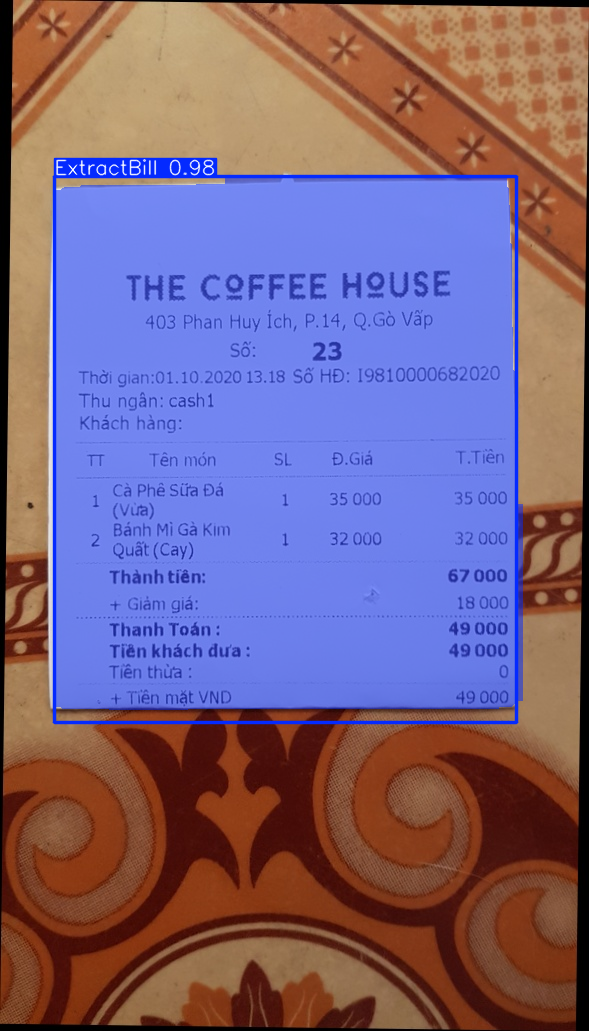

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0.], device='cuda:0')
conf: tensor([0.9841], device='cuda:0')
data: tensor([[ 54.6690, 176.0132, 516.1968, 722.3103,   0.9841,   0.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (1031, 589)
shape: torch.Size([1, 6])
xywh: tensor([[285.4329, 449.1617, 461.5277, 546.2971]], device='cuda:0')
xywhn: tensor([[0.4846, 0.4357, 0.7836, 0.5299]], device='cuda:0')
xyxy: tensor([[ 54.6690, 176.0132, 516.1968, 722.3103]], device='cuda:0')
xyxyn: tensor([[0.0928, 0.1707, 0.8764, 0.7006]], device='cuda:0')


In [ ]:
from ultralytics import YOLO

model = YOLO("./runs/segment/train/weights/best.pt")

# Use one-to-one head (default, no NMS required)
results = model.predict("./Segmentation_Datasets/test/images/mcocr_public_145013clfsp_jpg.rf.XADEJTzj2EwRDvkrvIan.jpg")
# Access the results
for result in results:
    result.show()
    boxes = result.boxes  # Boxes object for bbox outputs
    print(boxes)
    masks = result.masks  # Masks object for segmentation masks outputs
    keypoints = result.keypoints  # Keypoints object for pose outputs
    probs = result.probs  # Probs object for classification outputs
    xy = result.masks.xy  # mask polygons in pixel coordinates
    xyn = result.masks.xyn  # normalized mask polygons
    masks = result.masks.data  # binary masks, shape (N,H,W), dtype torch.uint8

# Tiền xử lý ảnh cho các bước tiếp theo


image 1/1 /content/drive/MyDrive/Cole_Giảng dạy/OCR_Understanding Document/OCR_Document/Phase 1 Tổng quan về mô hình ai truyền thống/Buổi 2 - Text Detection/Code/Segmentation_Datasets/test/images/mcocr_public_145013clfsp_jpg.rf.XADEJTzj2EwRDvkrvIan.jpg: 640x384 1 ExtractBill, 32.9ms
Speed: 6.2ms preprocess, 32.9ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 384)


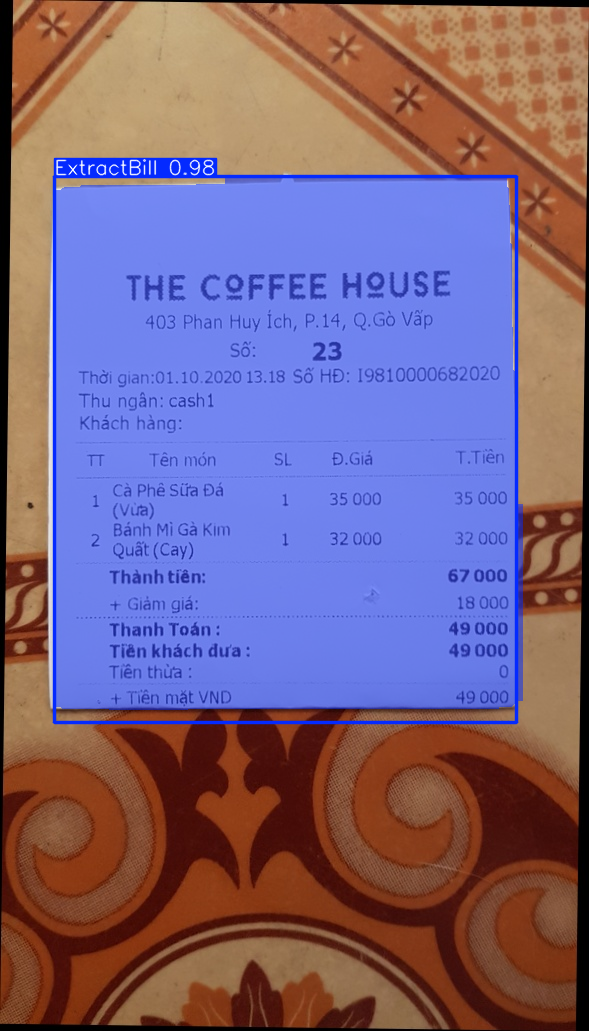

Bill #0: shape=(468, 531, 3)


In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np

model = YOLO("./runs/segment/train/weights/best.pt")

img_path = "./Segmentation_Datasets/test/images/mcocr_public_145013clfsp_jpg.rf.XADEJTzj2EwRDvkrvIan.jpg"
results = model.predict(img_path)

result = results[0]
result.show()

orig_img = result.orig_img  # ảnh gốc BGR


# ============================================================
# HÀM: Sắp xếp 4 điểm góc theo thứ tự chuẩn
# ============================================================
def order_points(pts):
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1)
    return np.array([
        pts[np.argmin(s)],      # top-left
        pts[np.argmin(diff)],   # top-right
        pts[np.argmax(s)],      # bottom-right
        pts[np.argmax(diff)],   # bottom-left
    ], dtype=np.float32)


# ============================================================
# HÀM: Làm đen nền ngoài polygon (giữ màu bên trong)
# ============================================================
def apply_black_background(orig_img, poly):
    poly_int = poly.astype(np.int32)
    mask = np.zeros(orig_img.shape[:2], dtype=np.uint8)
    cv2.fillPoly(mask, [poly_int], 255)  # vùng bill = 255, nền = 0
    masked = cv2.bitwise_and(orig_img, orig_img, mask=mask)  # nền tự động thành đen (0,0,0)
    return masked


# ============================================================
# HÀM: Warp polygon về hình chữ nhật thẳng (giữ nguyên màu)
# ============================================================
def warp_bill(img_with_black_bg, poly):
    poly = poly.astype(np.float32)
    rect = cv2.minAreaRect(poly)
    box = cv2.boxPoints(rect)
    src_pts = order_points(box)

    (w, h) = rect[1]
    w, h = int(w), int(h)
    if w < h:  # ép về chiều ngang > dọc (đúng chiều đọc bill)
        w, h = h, w
        src_pts = np.roll(src_pts, 1, axis=0)

    dst_pts = np.array([[0, 0], [w - 1, 0], [w - 1, h - 1], [0, h - 1]], dtype=np.float32)
    M = cv2.getPerspectiveTransform(src_pts, dst_pts)
    warped = cv2.warpPerspective(img_with_black_bg, M, (w, h))
    return warped


# ============================================================
# CHẠY: mask nền đen -> warp -> lưu ảnh MÀU (không grayscale) cho OCR
# ============================================================
if result.masks is not None:
    for j, poly in enumerate(result.masks.xy):
        black_bg_img = apply_black_background(orig_img, poly)  # nền đen, giữ màu bill
        warped = warp_bill(black_bg_img, poly)                 # duỗi thẳng góc nghiêng

        cv2.imwrite(f"final_bill_{j}.jpg", warped)  # ảnh MÀU, sẵn sàng feed PaddleOCR
        print(f"Bill #{j}: shape={warped.shape}")
else:
    print("Không có mask -> không detect được bill nào")

# Tạo bộ dữ liệu cho các bước sau

In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
import os
from glob import glob
from tqdm import tqdm


# ============================================================
# HÀM PHỤ: làm đen nền ngoài polygon
# ============================================================
def apply_black_background(orig_img, poly):
    poly_int = poly.astype(np.int32)
    mask = np.zeros(orig_img.shape[:2], dtype=np.uint8)
    cv2.fillPoly(mask, [poly_int], 255)
    return cv2.bitwise_and(orig_img, orig_img, mask=mask)


# ============================================================
# HÀM PHỤ: xoay theo góc nghiêng + crop theo bounding box
# ============================================================
def rotate_and_crop(img_with_black_bg, poly):
    poly_int = poly.astype(np.int32)
    rect = cv2.minAreaRect(poly)
    angle = rect[2]

    h_img, w_img = img_with_black_bg.shape[:2]
    center = (w_img // 2, h_img // 2)

    if angle < -45:
        angle += 90

    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(img_with_black_bg, M, (w_img, h_img),
                              flags=cv2.INTER_CUBIC, borderValue=(0, 0, 0))

    # xoay polygon theo cùng ma trận để tính lại bounding box đúng vị trí mới
    ones = np.ones((poly_int.shape[0], 1))
    poly_hom = np.hstack([poly_int, ones])
    rotated_poly = (M @ poly_hom.T).T.astype(np.int32)

    x, y, w, h = cv2.boundingRect(rotated_poly)
    x, y = max(0, x), max(0, y)
    if w <= 0 or h <= 0:
        return None
    return rotated[y:y+h, x:x+w]


# ============================================================
# HÀM CHÍNH: chạy full train/valid/test -> lưu chung 1 folder
# ============================================================
def process_all_splits(
    model_path,
    dataset_root,
    output_dir,
    splits=("train", "valid", "test"),
    images_subdir="images",
    conf=0.25,
    img_exts=(".jpg", ".jpeg", ".png"),
):
    os.makedirs(output_dir, exist_ok=True)
    model = YOLO(model_path)

    log_no_detect = []
    log_error = []
    total_saved = 0

    for split in splits:
        split_dir = os.path.join(dataset_root, split, images_subdir)
        if not os.path.isdir(split_dir):
            print(f"[SKIP] Không tìm thấy folder: {split_dir}")
            continue

        img_paths = [
            p for p in glob(os.path.join(split_dir, "*"))
            if os.path.splitext(p)[1].lower() in img_exts
        ]
        print(f"\n[{split}] Tìm thấy {len(img_paths)} ảnh")

        for img_path in tqdm(img_paths, desc=f"Processing {split}"):
            try:
                results = model.predict(img_path, conf=conf, verbose=False)
                r = results[0]
                orig_img = r.orig_img
                base_name = os.path.splitext(os.path.basename(img_path))[0]

                if r.masks is None or len(r.masks.xy) == 0:
                    log_no_detect.append(img_path)
                    continue

                for j, poly in enumerate(r.masks.xy):
                    black_bg_img = apply_black_background(orig_img, poly)
                    cropped = rotate_and_crop(black_bg_img, poly)

                    if cropped is None:
                        continue

                    out_name = f"{split}_{base_name}_{j}.jpg"
                    out_path = os.path.join(output_dir, out_name)
                    cv2.imwrite(out_path, cropped)
                    total_saved += 1

            except Exception as e:
                log_error.append((img_path, str(e)))

    print(f"\n{'='*50}")
    print(f"Tổng ảnh đã lưu: {total_saved}")
    print(f"Ảnh không detect được: {len(log_no_detect)}")
    print(f"Ảnh lỗi: {len(log_error)}")
    if log_no_detect:
        print("\nDanh sách ảnh không detect (10 đầu):")
        for p in log_no_detect[:10]:
            print(" -", p)
    if log_error:
        print("\nDanh sách ảnh lỗi:")
        for p, e in log_error:
            print(" -", p, "|", e)

    return {
        "total_saved": total_saved,
        "no_detect": log_no_detect,
        "errors": log_error,
    }


# ============================================================
# CHẠY
# ============================================================
report = process_all_splits(
    model_path="./runs/segment/train/weights/best.pt",
    dataset_root="./Segmentation_Datasets",
    output_dir="./warped_bills",
    splits=("train", "valid", "test"),
)


[train] Tìm thấy 73 ảnh


Processing train: 100%|██████████| 73/73 [00:06<00:00, 11.29it/s]



[valid] Tìm thấy 17 ảnh


Processing valid: 100%|██████████| 17/17 [00:01<00:00, 12.93it/s]



[test] Tìm thấy 9 ảnh


Processing test: 100%|██████████| 9/9 [00:00<00:00, 13.80it/s]


Tổng ảnh đã lưu: 108
Ảnh không detect được: 3
Ảnh lỗi: 0

Danh sách ảnh không detect (10 đầu):
 - ./Segmentation_Datasets/train/images/mcocr_public_145013cixex_jpg.rf.lW6tDS3BIUr9XnciJy16.jpg
 - ./Segmentation_Datasets/valid/images/mcocr_public_145014qbdep_jpg.rf.FodlLlZtFeS8IJWowDVt.jpg
 - ./Segmentation_Datasets/test/images/mcocr_public_145013crqqo_jpg.rf.ZRJtVTJrQrv59UUjV5rg.jpg
